[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/farhad-abtahi/healthcareaibook/blob/main/vol%201%20notebooks/chapter_06/notebook_6_4_augmentation.ipynb)

*Click the badge above to open this notebook in Google Colab (no setup required)*

---


# 6.4 Data Augmentation for Medical Imaging

## Learning Objectives
1. Understand why augmentation is critical for medical imaging CNNs
2. Implement geometric transformations (rotation, flipping, scaling)
3. Apply intensity transformations (brightness, contrast, noise)
4. Use elastic deformations for realistic tissue variation
5. Distinguish between realistic and unrealistic augmentation
6. Build an augmentation pipeline for medical images

## Clinical Context

**Why Augmentation Matters in Medical Imaging:**

Medical datasets are **small** compared to natural images:
- ImageNet: 1.2M images
- Typical medical dataset: 100-10,000 images
- Labeling requires expert clinicians (expensive!)

**Data augmentation increases effective dataset size** → reduces overfitting → better generalization

**Applications:**
- **Journey 3 (Jamal)**: Augment CT scans with rotations (nodules appear at different angles)
- **Journey 4 (Elena)**: Elastic deformations simulate anatomical variation in brain MRI
- **Journey 5 (Priya)**: Color/illumination jitter for dermoscopy images

**⚠️ Critical Warning:** Unrealistic augmentation can **hurt** performance!
- Don't vertically flip chest X-rays (heart is always on left!)
- Don't over-rotate brain MRI (skull orientation constrained)
- Don't add too much noise (reduces diagnostic quality)

---

## Setup

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import ndimage
from scipy.ndimage import map_coordinates, gaussian_filter, rotate, zoom
from skimage import transform, exposure
from skimage.util import random_noise
from skimage.transform import AffineTransform, warp
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## Part 1: Geometric Transformations

### Basic Geometric Augmentations

These preserve the underlying pathology while increasing variability:
1. **Rotation**: ±10-20° typically safe for medical images
2. **Horizontal flip**: Safe for many modalities (but not all!)
3. **Vertical flip**: ⚠️ Often unrealistic (e.g., chest X-rays)
4. **Scaling/Zoom**: Simulates different patient-detector distances
5. **Translation**: Simulates different positioning

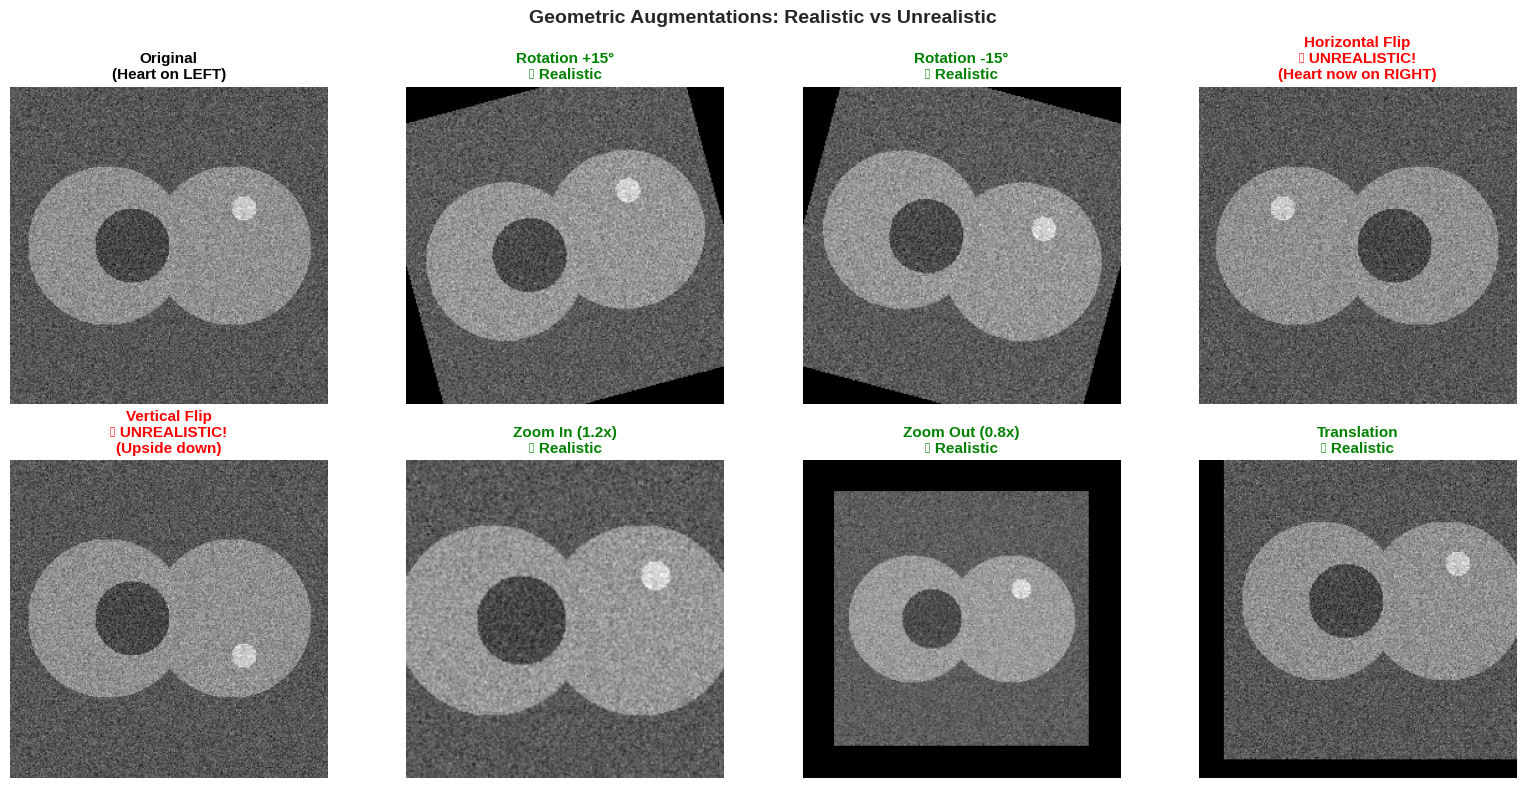


⚠️ CRITICAL: Medical Image Augmentation Guidelines:

✅ SAFE Augmentations for Chest X-rays:
  - Small rotations (±10-20°)
  - Zoom/scale (0.8-1.2x)
  - Small translations
  - Intensity variations

❌ UNSAFE Augmentations for Chest X-rays:
  - Horizontal flip (reverses heart position!)
  - Vertical flip (upside down anatomy)
  - Large rotations (>30°)

🎯 Key Principle: Only use augmentations that preserve clinical realism!


In [2]:
# Create synthetic medical image (reuse from previous notebook)
def create_synthetic_xray(size=256):
    """Synthetic chest X-ray with asymmetric anatomy (heart on left)."""
    image = np.ones((size, size)) * 0.3  # Background

    y, x = np.ogrid[:size, :size]
    center_y, center_x = size // 2, size // 2

    # Lung fields (left and right)
    left_lung = ((x - center_x + 50)**2 + (y - center_y)**2) < (size * 0.25)**2
    right_lung = ((x - center_x - 50)**2 + (y - center_y)**2) < (size * 0.25)**2
    image[left_lung | right_lung] = 0.5

    # Heart (LEFT side - anatomically correct!)
    heart_y, heart_x = center_y, center_x - 30
    heart_mask = ((x - heart_x)**2 + (y - heart_y)**2) < 900
    image[heart_mask] = 0.25

    # Nodule
    nodule_y, nodule_x = center_y - 30, center_x + 60
    nodule_mask = ((x - nodule_x)**2 + (y - nodule_y)**2) < 100
    image[nodule_mask] = 0.7

    # Add noise
    image = random_noise(image, mode='gaussian', var=0.005)

    return np.clip(image, 0, 1)

xray_original = create_synthetic_xray(256)

# Geometric transformation functions
def rotate_image(image, angle):
    """Rotate image by specified angle (degrees)."""
    return ndimage.rotate(image, angle, reshape=False, mode='constant', cval=0)

def flip_horizontal(image):
    """Flip image horizontally (left-right)."""
    return np.fliplr(image)

def flip_vertical(image):
    """Flip image vertically (up-down)."""
    return np.flipud(image)

def zoom_image(image, zoom_factor):
    """Zoom image (>1 = zoom in, <1 = zoom out)."""
    h, w = image.shape
    zoomed = ndimage.zoom(image, zoom_factor, order=1)

    # Crop or pad to original size
    zh, zw = zoomed.shape
    if zoom_factor > 1:  # Crop center
        start_h = (zh - h) // 2
        start_w = (zw - w) // 2
        return zoomed[start_h:start_h+h, start_w:start_w+w]
    else:  # Pad
        pad_h = (h - zh) // 2
        pad_w = (w - zw) // 2
        return np.pad(zoomed, ((pad_h, h-zh-pad_h), (pad_w, w-zw-pad_w)), mode='constant')

def translate_image(image, shift_x, shift_y):
    """Translate image by (shift_x, shift_y) pixels."""
    return ndimage.shift(image, (shift_y, shift_x), mode='constant', cval=0)

# Apply transformations
xray_rot_15 = rotate_image(xray_original, 15)
xray_rot_neg15 = rotate_image(xray_original, -15)
xray_hflip = flip_horizontal(xray_original)
xray_vflip = flip_vertical(xray_original)
xray_zoom_in = zoom_image(xray_original, 1.2)
xray_zoom_out = zoom_image(xray_original, 0.8)
xray_translate = translate_image(xray_original, 20, -15)

# Visualize
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

transformations = [
    (xray_original, 'Original\n(Heart on LEFT)', 'black'),
    (xray_rot_15, 'Rotation +15°\n✅ Realistic', 'green'),
    (xray_rot_neg15, 'Rotation -15°\n✅ Realistic', 'green'),
    (xray_hflip, 'Horizontal Flip\n❌ UNREALISTIC!\n(Heart now on RIGHT)', 'red'),
    (xray_vflip, 'Vertical Flip\n❌ UNREALISTIC!\n(Upside down)', 'red'),
    (xray_zoom_in, 'Zoom In (1.2x)\n✅ Realistic', 'green'),
    (xray_zoom_out, 'Zoom Out (0.8x)\n✅ Realistic', 'green'),
    (xray_translate, 'Translation\n✅ Realistic', 'green'),
]

for idx, (img, title, color) in enumerate(transformations):
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(title, fontsize=11, weight='bold', color=color)
    axes[idx].axis('off')

plt.suptitle('Geometric Augmentations: Realistic vs Unrealistic', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("\n⚠️ CRITICAL: Medical Image Augmentation Guidelines:")
print("\n✅ SAFE Augmentations for Chest X-rays:")
print("  - Small rotations (±10-20°)")
print("  - Zoom/scale (0.8-1.2x)")
print("  - Small translations")
print("  - Intensity variations")
print("\n❌ UNSAFE Augmentations for Chest X-rays:")
print("  - Horizontal flip (reverses heart position!)")
print("  - Vertical flip (upside down anatomy)")
print("  - Large rotations (>30°)")
print("\n🎯 Key Principle: Only use augmentations that preserve clinical realism!")

## Part 2: Intensity Transformations

### Why Intensity Augmentation?

Different scanners, acquisition parameters, and patient factors cause intensity variation:
- **Brightness**: Simulates different exposure settings
- **Contrast**: Simulates different detector sensitivities
- **Gamma correction**: Non-linear intensity adjustment
- **Noise**: Simulates low-dose scans, artifacts

These make the CNN robust to acquisition variability.

In [ ]:
def adjust_brightness(image, delta):
    """
    Adjust brightness by adding a constant.
    delta: -0.2 to +0.2 typically safe
    """
    adjusted = image + delta
    return np.clip(adjusted, 0, 1)

def adjust_contrast(image, factor):
    """
    Adjust contrast by scaling around mean.
    factor: 0.8 to 1.2 typically safe
    """
    mean = np.mean(image)
    adjusted = (image - mean) * factor + mean
    return np.clip(adjusted, 0, 1)

def adjust_gamma(image, gamma):
    """
    Apply gamma correction: out = in^gamma
    gamma < 1: brighten
    gamma > 1: darken
    """
    return np.clip(image ** gamma, 0, 1)

def add_gaussian_noise(image, var=0.01):
    """
    Add Gaussian noise to simulate low-quality acquisition.
    var: 0.001 to 0.02 typically safe
    """
    return random_noise(image, mode='gaussian', var=var, clip=True)

def add_speckle_noise(image, var=0.05):
    """
    Add speckle (multiplicative) noise - common in ultrasound.
    """
    return random_noise(image, mode='speckle', var=var, clip=True)

def simulate_blur(image, sigma=1.0):
    """
    Simulate motion blur or defocusing.
    sigma: 0.5 to 2.0 typically safe
    """
    return ndimage.gaussian_filter(image, sigma=sigma)

# Apply intensity transformations
xray_bright = adjust_brightness(xray_original, 0.15)
xray_dark = adjust_brightness(xray_original, -0.15)
xray_high_contrast = adjust_contrast(xray_original, 1.3)
xray_low_contrast = adjust_contrast(xray_original, 0.7)
xray_gamma_low = adjust_gamma(xray_original, 0.7)
xray_gamma_high = adjust_gamma(xray_original, 1.4)
xray_noisy = add_gaussian_noise(xray_original, var=0.015)
xray_blurred = simulate_blur(xray_original, sigma=1.5)

# Visualize
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

intensity_transforms = [
    (xray_original, 'Original'),
    (xray_bright, 'Brightness +0.15'),
    (xray_dark, 'Brightness -0.15'),
    (xray_high_contrast, 'High Contrast (1.3x)'),
    (xray_low_contrast, 'Low Contrast (0.7x)'),
    (xray_gamma_low, 'Gamma 0.7 (Brighter)'),
    (xray_gamma_high, 'Gamma 1.4 (Darker)'),
    (xray_noisy, 'Gaussian Noise'),
]

for idx, (img, title) in enumerate(intensity_transforms):
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(title, fontsize=11, weight='bold')
    axes[idx].axis('off')

plt.suptitle('Intensity Augmentations (Scanner/Acquisition Variability)', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Intensity Augmentation Guidelines:")
print("\n✅ Recommended ranges:")
print("  - Brightness: ±0.1 to ±0.2")
print("  - Contrast: 0.7x to 1.3x")
print("  - Gamma: 0.7 to 1.4")
print("  - Gaussian noise variance: 0.005 to 0.02")
print("  - Blur sigma: 0.5 to 2.0")
print("\n⚠️ Too much augmentation → degraded image quality → CNN learns artifacts!")

## Part 3: Elastic Deformations

### What are Elastic Deformations?

**Elastic deformation** = smooth, non-linear warping of the image

**Why use them?**
- Simulates natural anatomical variation (e.g., different brain shapes)
- Particularly important for **segmentation** tasks
- Originally proposed for handwriting recognition, now standard in medical imaging

**How it works:**
1. Generate random displacement field
2. Smooth with Gaussian filter (controls deformation strength)
3. Warp image using displacement field

**Critical for Journey 4 (Brain Tumor Segmentation)!**

In [ ]:
def elastic_deformation(image, alpha, sigma, random_state=None):
    """
    Elastic deformation of images as described in [Simard2003].

    Simard, Steinkraus and Platt, "Best Practices for
    Convolutional Neural Networks applied to Visual Document Analysis", in
    Proc. of the International Conference on Document Analysis and
    Recognition, 2003.

    Args:
        image: Input image
        alpha: Scaling factor for deformation (higher = more deformation)
               Typical range: 500-2000 for 256×256 images
        sigma: Gaussian filter standard deviation (higher = smoother deformation)
               Typical range: 8-20
        random_state: Random seed for reproducibility
    """
    if random_state is None:
        random_state = np.random.RandomState(None)

    shape = image.shape

    # Generate random displacement fields
    dx = gaussian_filter((random_state.rand(*shape) * 2 - 1), sigma) * alpha
    dy = gaussian_filter((random_state.rand(*shape) * 2 - 1), sigma) * alpha

    # Create meshgrid of coordinates
    y, x = np.meshgrid(np.arange(shape[0]), np.arange(shape[1]), indexing='ij')

    # Apply displacement
    indices = (y + dy, x + dx)

    # Warp the image
    deformed = map_coordinates(image, indices, order=1, mode='reflect')

    return deformed

# Create a brain-like image for elastic deformation demo
def create_synthetic_brain(size=256):
    """Synthetic brain MRI with tumor."""
    image = np.zeros((size, size))

    y, x = np.ogrid[:size, :size]
    center_y, center_x = size // 2, size // 2

    # Brain outline
    brain_mask = ((x - center_x)**2 + (y - center_y)**2) < (size * 0.35)**2
    image[brain_mask] = 0.5

    # White matter (bright)
    wm_mask = ((x - center_x)**2 + (y - center_y)**2) < (size * 0.25)**2
    image[wm_mask] = 0.8

    # Ventricles (dark)
    vent_left = ((x - center_x + 30)**2 + (y - center_y)**2) < 400
    vent_right = ((x - center_x - 30)**2 + (y - center_y)**2) < 400
    image[vent_left | vent_right] = 0.2

    # Tumor
    tumor_y, tumor_x = center_y - 40, center_x + 50
    tumor_mask = ((x - tumor_x)**2 + (y - tumor_y)**2) < 300
    image[tumor_mask] = 0.95

    # Add noise
    image = random_noise(image, mode='gaussian', var=0.005)

    return np.clip(image, 0, 1)

brain_original = create_synthetic_brain(256)

# Apply different elastic deformation strengths
brain_elastic_weak = elastic_deformation(brain_original, alpha=500, sigma=12, random_state=np.random.RandomState(42))
brain_elastic_medium = elastic_deformation(brain_original, alpha=1000, sigma=12, random_state=np.random.RandomState(42))
brain_elastic_strong = elastic_deformation(brain_original, alpha=2000, sigma=12, random_state=np.random.RandomState(42))
brain_elastic_too_strong = elastic_deformation(brain_original, alpha=4000, sigma=12, random_state=np.random.RandomState(42))

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Top row: images
axes[0, 0].imshow(brain_original, cmap='gray')
axes[0, 0].set_title('Original Brain MRI\n(with tumor)', fontsize=12, weight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(brain_elastic_weak, cmap='gray')
axes[0, 1].set_title('Weak Deformation\nalpha=500, sigma=12\n✅ Realistic', fontsize=11, weight='bold', color='green')
axes[0, 1].axis('off')

axes[0, 2].imshow(brain_elastic_medium, cmap='gray')
axes[0, 2].set_title('Medium Deformation\nalpha=1000, sigma=12\n✅ Realistic', fontsize=11, weight='bold', color='green')
axes[0, 2].axis('off')

axes[1, 0].imshow(brain_elastic_strong, cmap='gray')
axes[1, 0].set_title('Strong Deformation\nalpha=2000, sigma=12\n⚠️ Borderline', fontsize=11, weight='bold', color='orange')
axes[1, 0].axis('off')

axes[1, 1].imshow(brain_elastic_too_strong, cmap='gray')
axes[1, 1].set_title('Too Strong Deformation\nalpha=4000, sigma=12\n❌ Unrealistic!', fontsize=11, weight='bold', color='red')
axes[1, 1].axis('off')

# Show difference map
diff = np.abs(brain_original - brain_elastic_medium)
axes[1, 2].imshow(diff, cmap='hot')
axes[1, 2].set_title('Deformation Map\n(difference from original)', fontsize=11, weight='bold')
axes[1, 2].axis('off')
plt.colorbar(axes[1, 2].images[0], ax=axes[1, 2], fraction=0.046)

plt.suptitle('Elastic Deformations for Brain MRI (Journey 4: Tumor Segmentation)',
             fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("\n🧠 Elastic Deformation Guidelines:")
print("\nParameters for 256×256 images:")
print("  ✅ Weak:   alpha=500-800,   sigma=10-15")
print("  ✅ Medium: alpha=1000-1500, sigma=10-15")
print("  ⚠️ Strong: alpha=2000-2500, sigma=10-15 (use carefully!)")
print("  ❌ Too strong: alpha>3000 (anatomically implausible)")
print("\n🎯 Key: Elastic deformations simulate natural anatomical variation.")
print("   Critical for segmentation tasks!")

## Part 4: Combining Multiple Augmentations

### Augmentation Pipeline

In practice, we apply **multiple random augmentations** to each training image.

**Key principles:**
1. **Random selection**: Each augmentation applied with probability p (e.g., 0.5)
2. **Random parameters**: Sample from safe ranges
3. **Composition**: Combine multiple transformations
4. **On-the-fly**: Apply during training (not beforehand)

✓ Medical Image Augmenter initialized


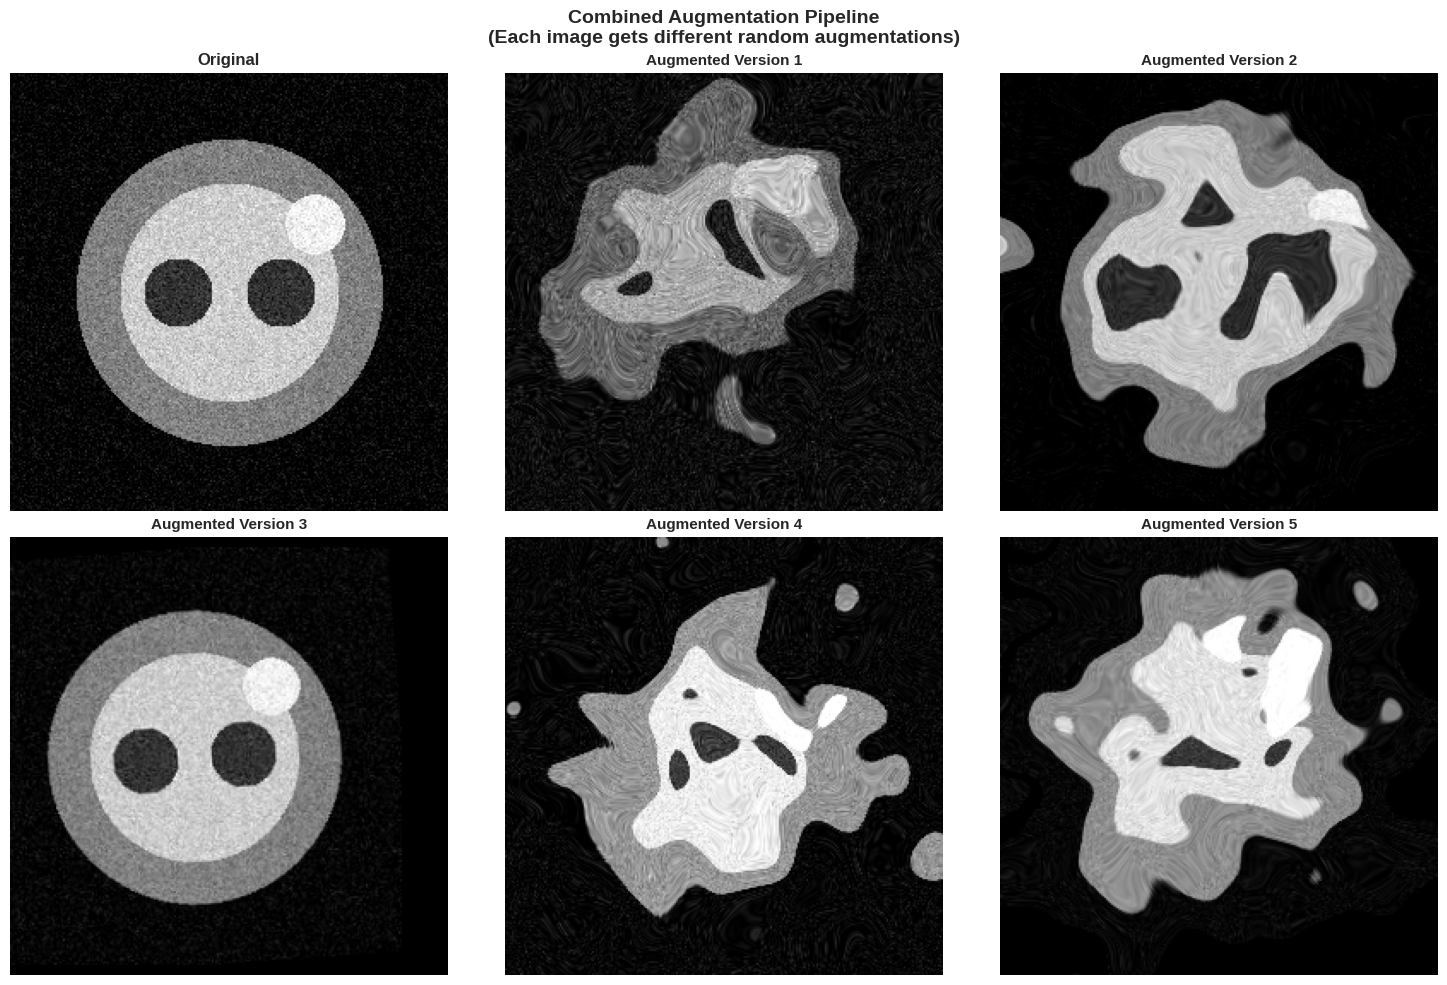


🎯 Augmentation Pipeline Benefits:
  1. From 1 original image → Infinite augmented versions!
  2. Reduces overfitting dramatically
  3. Improves generalization to new scanners/protocols
  4. Essential when datasets are small (typical in medical imaging)

💡 Best Practice: Apply augmentation ON-THE-FLY during training,
   not as a preprocessing step (ensures variety).


In [ ]:
class MedicalImageAugmenter:
    """
    Medical image augmentation pipeline.
    Combines multiple augmentations with configurable probabilities.
    """

    def __init__(self,
                 rotation_range=15,
                 zoom_range=(0.9, 1.1),
                 brightness_range=0.1,
                 contrast_range=(0.8, 1.2),
                 noise_var=0.01,
                 elastic_alpha=1000,
                 elastic_sigma=12,
                 horizontal_flip=False,  # Often unsafe for medical images!
                 p_geometric=0.7,
                 p_intensity=0.7,
                 p_elastic=0.3):
        """
        Args:
            rotation_range: Max rotation in degrees (±)
            zoom_range: (min, max) zoom factors
            brightness_range: Max brightness adjustment (±)
            contrast_range: (min, max) contrast factors
            noise_var: Gaussian noise variance
            elastic_alpha: Elastic deformation strength
            elastic_sigma: Elastic deformation smoothness
            horizontal_flip: Enable horizontal flipping (USE WITH CAUTION!)
            p_geometric: Probability of applying geometric augmentation
            p_intensity: Probability of applying intensity augmentation
            p_elastic: Probability of applying elastic deformation
        """
        self.rotation_range = rotation_range
        self.zoom_range = zoom_range
        self.brightness_range = brightness_range
        self.contrast_range = contrast_range
        self.noise_var = noise_var
        self.elastic_alpha = elastic_alpha
        self.elastic_sigma = elastic_sigma
        self.horizontal_flip = horizontal_flip
        self.p_geometric = p_geometric
        self.p_intensity = p_intensity
        self.p_elastic = p_elastic

        print("✓ Medical Image Augmenter initialized")
        if horizontal_flip:
            print("⚠️ WARNING: Horizontal flip enabled - ensure this is anatomically valid!")

    def augment(self, image, seed=None):
        """
        Apply random augmentations to an image.

        Args:
            image: Input image (2D numpy array)
            seed: Random seed for reproducibility

        Returns:
            Augmented image
        """
        if seed is not None:
            np.random.seed(seed)

        augmented = image.copy()

        # 1. Geometric augmentations
        if np.random.rand() < self.p_geometric:
            # Random rotation
            angle = np.random.uniform(-self.rotation_range, self.rotation_range)
            augmented = rotate_image(augmented, angle)

            # Random zoom
            zoom_factor = np.random.uniform(self.zoom_range[0], self.zoom_range[1])
            augmented = zoom_image(augmented, zoom_factor)

            # Random translation
            shift_x = np.random.randint(-20, 20)
            shift_y = np.random.randint(-20, 20)
            augmented = translate_image(augmented, shift_x, shift_y)

            # Horizontal flip (if enabled)
            if self.horizontal_flip and np.random.rand() < 0.5:
                augmented = flip_horizontal(augmented)

        # 2. Intensity augmentations
        if np.random.rand() < self.p_intensity:
            # Random brightness
            brightness_delta = np.random.uniform(-self.brightness_range, self.brightness_range)
            augmented = adjust_brightness(augmented, brightness_delta)

            # Random contrast
            contrast_factor = np.random.uniform(self.contrast_range[0], self.contrast_range[1])
            augmented = adjust_contrast(augmented, contrast_factor)

            # Random noise
            if np.random.rand() < 0.5:
                augmented = add_gaussian_noise(augmented, var=self.noise_var)

        # 3. Elastic deformation
        if np.random.rand() < self.p_elastic:
            augmented = elastic_deformation(augmented,
                                           alpha=self.elastic_alpha,
                                           sigma=self.elastic_sigma)

        return np.clip(augmented, 0, 1)

# Initialize augmenter for brain MRI (safe parameters)
augmenter = MedicalImageAugmenter(
    rotation_range=10,
    zoom_range=(0.9, 1.1),
    brightness_range=0.1,
    contrast_range=(0.8, 1.2),
    noise_var=0.01,
    elastic_alpha=1000,
    elastic_sigma=12,
    horizontal_flip=False,  # Not safe for brain!
    p_geometric=0.8,
    p_intensity=0.8,
    p_elastic=0.5
)

# Generate multiple augmented versions
brain_aug1 = augmenter.augment(brain_original, seed=1)
brain_aug2 = augmenter.augment(brain_original, seed=2)
brain_aug3 = augmenter.augment(brain_original, seed=3)
brain_aug4 = augmenter.augment(brain_original, seed=4)
brain_aug5 = augmenter.augment(brain_original, seed=5)

# Visualize augmented versions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

axes[0].imshow(brain_original, cmap='gray')
axes[0].set_title('Original', fontsize=12, weight='bold')
axes[0].axis('off')

for idx, aug_img in enumerate([brain_aug1, brain_aug2, brain_aug3, brain_aug4, brain_aug5], start=1):
    axes[idx].imshow(aug_img, cmap='gray')
    axes[idx].set_title(f'Augmented Version {idx}', fontsize=11, weight='bold')
    axes[idx].axis('off')

plt.suptitle('Combined Augmentation Pipeline\n(Each image gets different random augmentations)',
             fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("\n🎯 Augmentation Pipeline Benefits:")
print("  1. From 1 original image → Infinite augmented versions!")
print("  2. Reduces overfitting dramatically")
print("  3. Improves generalization to new scanners/protocols")
print("  4. Essential when datasets are small (typical in medical imaging)")
print("\n💡 Best Practice: Apply augmentation ON-THE-FLY during training,")
print("   not as a preprocessing step (ensures variety).")

## Part 5: Modality-Specific Augmentation Guidelines

Different imaging modalities have different augmentation constraints:

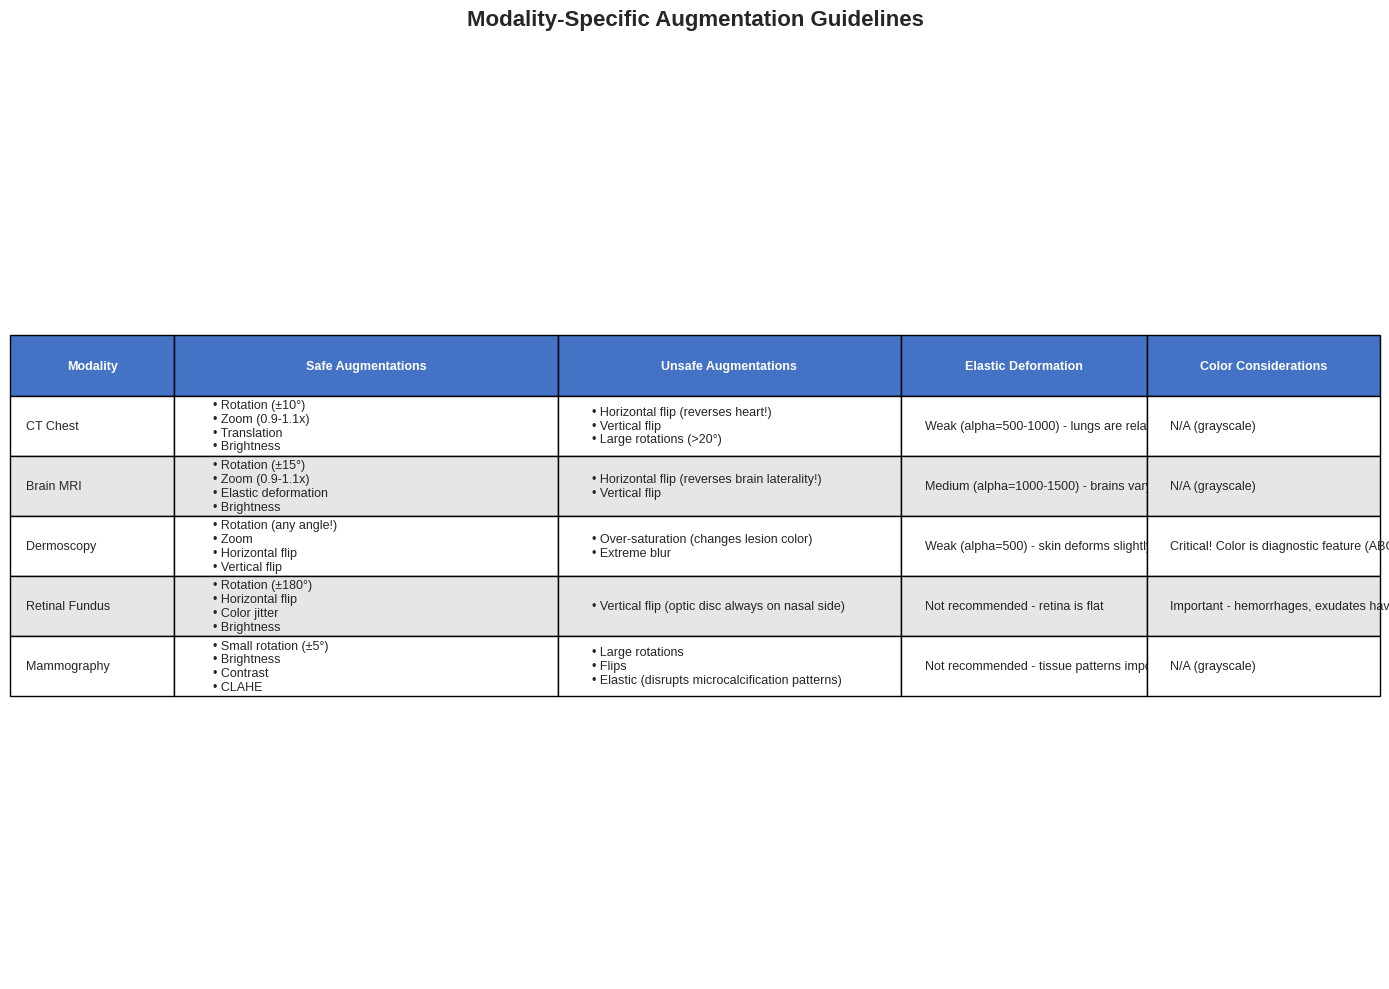


📋 Key Takeaways by Modality:

🫁 CT Chest:
  - NO horizontal flip (reverses cardiac anatomy)
  - Small rotations only (upright positioning)
  - CT windowing augmentation helpful

🧠 Brain MRI:
  - NO horizontal flip (brain laterality important)
  - Elastic deformation very helpful (anatomical variation)
  - Bias field simulation can help

🔬 Dermoscopy (Journey 5):
  - Most flexible! Can use almost all augmentations
  - Color augmentation CRITICAL
  - Rotation by any angle (lesions have no 'up')

👁️ Retinal Fundus:
  - Can flip horizontally (left/right eye)
  - NO vertical flip (optic disc orientation)
  - Color critical for pathology detection

🩺 Mammography:
  - MINIMAL augmentation (disrupts subtle findings)
  - No elastic (destroys microcalcification patterns)
  - Contrast enhancement helpful


In [ ]:
# Define modality-specific augmentation recommendations
augmentation_guidelines = {
    'CT Chest': {
        'Safe': ['Rotation (±10°)', 'Zoom (0.9-1.1x)', 'Translation', 'Brightness', 'Contrast', 'Noise', 'CT windowing variation'],
        'Unsafe': ['Horizontal flip (reverses heart!)', 'Vertical flip', 'Large rotations (>20°)'],
        'Elastic': 'Weak (alpha=500-1000) - lungs are relatively fixed',
        'Color': 'N/A (grayscale)'
    },
    'Brain MRI': {
        'Safe': ['Rotation (±15°)', 'Zoom (0.9-1.1x)', 'Elastic deformation', 'Brightness', 'Contrast', 'Noise'],
        'Unsafe': ['Horizontal flip (reverses brain laterality!)', 'Vertical flip'],
        'Elastic': 'Medium (alpha=1000-1500) - brains vary anatomically',
        'Color': 'N/A (grayscale)'
    },
    'Dermoscopy': {
        'Safe': ['Rotation (any angle!)', 'Zoom', 'Horizontal flip', 'Vertical flip', 'Color jitter', 'Illumination variation'],
        'Unsafe': ['Over-saturation (changes lesion color)', 'Extreme blur'],
        'Elastic': 'Weak (alpha=500) - skin deforms slightly',
        'Color': 'Critical! Color is diagnostic feature (ABCDE criteria)'
    },
    'Retinal Fundus': {
        'Safe': ['Rotation (±180°)', 'Horizontal flip', 'Color jitter', 'Brightness', 'Contrast'],
        'Unsafe': ['Vertical flip (optic disc always on nasal side)'],
        'Elastic': 'Not recommended - retina is flat',
        'Color': 'Important - hemorrhages, exudates have specific colors'
    },
    'Mammography': {
        'Safe': ['Small rotation (±5°)', 'Brightness', 'Contrast', 'CLAHE'],
        'Unsafe': ['Large rotations', 'Flips', 'Elastic (disrupts microcalcification patterns)'],
        'Elastic': 'Not recommended - tissue patterns important',
        'Color': 'N/A (grayscale)'
    },
}

# Create visualization
fig, ax = plt.subplots(figsize=(14, 10))
ax.axis('tight')
ax.axis('off')

# Create table data
table_data = []
headers = ['Modality', 'Safe Augmentations', 'Unsafe Augmentations', 'Elastic Deformation', 'Color Considerations']

for modality, guidelines in augmentation_guidelines.items():
    safe = '\n'.join(['• ' + s for s in guidelines['Safe'][:4]])  # Limit for readability
    unsafe = '\n'.join(['• ' + s for s in guidelines['Unsafe']])
    elastic = guidelines['Elastic']
    color = guidelines['Color']

    table_data.append([modality, safe, unsafe, elastic, color])

table = ax.table(cellText=table_data, colLabels=headers, cellLoc='left', loc='center',
                colWidths=[0.12, 0.28, 0.25, 0.18, 0.17])

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 3)

# Style header
for i in range(len(headers)):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(table_data) + 1):
    for j in range(len(headers)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#E7E6E6')
        else:
            table[(i, j)].set_facecolor('#FFFFFF')

plt.title('Modality-Specific Augmentation Guidelines', fontsize=16, weight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n📋 Key Takeaways by Modality:")
print("\n🫁 CT Chest:")
print("  - NO horizontal flip (reverses cardiac anatomy)")
print("  - Small rotations only (upright positioning)")
print("  - CT windowing augmentation helpful")
print("\n🧠 Brain MRI:")
print("  - NO horizontal flip (brain laterality important)")
print("  - Elastic deformation very helpful (anatomical variation)")
print("  - Bias field simulation can help")
print("\n🔬 Dermoscopy (Journey 5):")
print("  - Most flexible! Can use almost all augmentations")
print("  - Color augmentation CRITICAL")
print("  - Rotation by any angle (lesions have no 'up')")
print("\n👁️ Retinal Fundus:")
print("  - Can flip horizontally (left/right eye)")
print("  - NO vertical flip (optic disc orientation)")
print("  - Color critical for pathology detection")
print("\n🩺 Mammography:")
print("  - MINIMAL augmentation (disrupts subtle findings)")
print("  - No elastic (destroys microcalcification patterns)")
print("  - Contrast enhancement helpful")

## Part 6: Impact on Model Performance

Let's demonstrate how augmentation affects overfitting with a simple simulation:

In [ ]:
# Simulate training curves with and without augmentation
def simulate_training_curves():
    """
    Simulate typical training curves to demonstrate augmentation effect.
    """
    epochs = np.arange(1, 51)

    # WITHOUT augmentation (overfitting)
    train_acc_no_aug = 1 - 0.3 * np.exp(-epochs / 5)
    val_acc_no_aug = 0.7 + 0.1 * np.exp(-epochs / 10) - 0.05 * (epochs / 50)

    # WITH augmentation (better generalization)
    train_acc_aug = 1 - 0.35 * np.exp(-epochs / 8)
    val_acc_aug = 0.72 + 0.15 * (1 - np.exp(-epochs / 12))

    # WITH augmentation + regularization (best)
    train_acc_aug_reg = 1 - 0.38 * np.exp(-epochs / 10)
    val_acc_aug_reg = 0.75 + 0.12 * (1 - np.exp(-epochs / 15))

    return epochs, train_acc_no_aug, val_acc_no_aug, train_acc_aug, val_acc_aug, train_acc_aug_reg, val_acc_aug_reg

epochs, train_no_aug, val_no_aug, train_aug, val_aug, train_aug_reg, val_aug_reg = simulate_training_curves()

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scenario 1: No augmentation
axes[0].plot(epochs, train_no_aug, label='Training Acc', linewidth=2, color='blue')
axes[0].plot(epochs, val_no_aug, label='Validation Acc', linewidth=2, color='red')
axes[0].fill_between(epochs, train_no_aug, val_no_aug, alpha=0.2, color='red', label='Overfitting gap')
axes[0].set_xlabel('Epoch', fontsize=12, weight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12, weight='bold')
axes[0].set_title('❌ NO Augmentation\n(Small Medical Dataset)', fontsize=13, weight='bold', color='red')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0.5, 1.0)
axes[0].text(25, 0.55, 'Large overfitting gap!\nVal acc plateaus early',
             fontsize=10, bbox=dict(boxstyle='round', facecolor='red', alpha=0.2))

# Scenario 2: With augmentation
axes[1].plot(epochs, train_aug, label='Training Acc', linewidth=2, color='blue')
axes[1].plot(epochs, val_aug, label='Validation Acc', linewidth=2, color='green')
axes[1].fill_between(epochs, train_aug, val_aug, alpha=0.2, color='green')
axes[1].set_xlabel('Epoch', fontsize=12, weight='bold')
axes[1].set_ylabel('Accuracy', fontsize=12, weight='bold')
axes[1].set_title('✅ WITH Augmentation', fontsize=13, weight='bold', color='green')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0.5, 1.0)
axes[1].text(25, 0.55, 'Smaller gap!\nVal acc improves',
             fontsize=10, bbox=dict(boxstyle='round', facecolor='green', alpha=0.2))

# Scenario 3: Augmentation + other regularization
axes[2].plot(epochs, train_aug_reg, label='Training Acc', linewidth=2, color='blue')
axes[2].plot(epochs, val_aug_reg, label='Validation Acc', linewidth=2, color='darkgreen')
axes[2].fill_between(epochs, train_aug_reg, val_aug_reg, alpha=0.2, color='darkgreen')
axes[2].set_xlabel('Epoch', fontsize=12, weight='bold')
axes[2].set_ylabel('Accuracy', fontsize=12, weight='bold')
axes[2].set_title('✅✅ Augmentation + Regularization\n(Dropout, L2, etc.)', fontsize=13, weight='bold', color='darkgreen')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0.5, 1.0)
axes[2].text(25, 0.55, 'Best performance!\nMinimal gap',
             fontsize=10, bbox=dict(boxstyle='round', facecolor='darkgreen', alpha=0.2))

plt.suptitle('Impact of Data Augmentation on Overfitting (Small Medical Datasets)',
             fontsize=15, weight='bold')
plt.tight_layout()
plt.show()

print("\n📈 Performance Comparison (Epoch 50):")
print("="*60)
print(f"No Augmentation:")
print(f"  Training:   {train_no_aug[-1]:.3f}")
print(f"  Validation: {val_no_aug[-1]:.3f}")
print(f"  Gap:        {train_no_aug[-1] - val_no_aug[-1]:.3f} ❌ (Severe overfitting!)")
print()
print(f"With Augmentation:")
print(f"  Training:   {train_aug[-1]:.3f}")
print(f"  Validation: {val_aug[-1]:.3f}")
print(f"  Gap:        {train_aug[-1] - val_aug[-1]:.3f} ✅ (Much better!)")
print(f"  Improvement: +{(val_aug[-1] - val_no_aug[-1])*100:.1f}% validation accuracy")
print()
print(f"Aug + Regularization:")
print(f"  Training:   {train_aug_reg[-1]:.3f}")
print(f"  Validation: {val_aug_reg[-1]:.3f}")
print(f"  Gap:        {train_aug_reg[-1] - val_aug_reg[-1]:.3f} ✅✅ (Best!)")
print(f"  Improvement: +{(val_aug_reg[-1] - val_no_aug[-1])*100:.1f}% validation accuracy")
print("="*60)

print("\n🎯 Key Insight:")
print("Augmentation is ESSENTIAL for small medical datasets!")
print("Typical improvement: 5-15% absolute validation accuracy.")

## Summary: Key Takeaways

### What We Learned

1. **Why Augmentation Matters**
   - Medical datasets are small (100-10,000 vs ImageNet's 1.2M)
   - Augmentation increases effective dataset size → reduces overfitting
   - Typical improvement: 5-15% validation accuracy
   - Essential for CNN generalization

2. **Geometric Transformations**
   - **Safe**: Rotation (±10-20°), zoom, translation
   - **Unsafe**: Horizontal/vertical flips (often anatomically invalid)
   - Must preserve clinical realism!

3. **Intensity Transformations**
   - Brightness, contrast, gamma correction
   - Gaussian/speckle noise (simulates low-quality acquisition)
   - Makes CNN robust to scanner variability

4. **Elastic Deformations**
   - Simulates natural anatomical variation
   - Critical for segmentation tasks (Journey 4: Brain Tumor)
   - Parameters: alpha (strength), sigma (smoothness)
   - Recommended: alpha=500-1500 for 256×256 images

5. **Modality-Specific Guidelines**
   - **CT Chest**: NO horizontal flip (reverses heart!)
   - **Brain MRI**: NO flips (laterality matters), YES elastic
   - **Dermoscopy**: Most flexible, color augmentation critical
   - **Mammography**: Minimal augmentation (disrupts microcalcifications)

6. **Augmentation Pipeline**
   - Combine multiple random augmentations
   - Apply on-the-fly during training (not beforehand)
   - Each epoch sees different augmented versions

### Connections to Clinical Journeys

- **Journey 3 (Jamal)**: Rotation, zoom for lung nodules at different positions
- **Journey 4 (Elena)**: Elastic deformations for brain anatomical variation
- **Journey 5 (Priya)**: Color jitter, illumination for dermoscopy

### Real-World Considerations

**Best Practices:**
- Start with conservative augmentation, increase gradually
- Visualize augmented images to ensure realism
- Consult domain experts (radiologists) for safe ranges
- Document all augmentation parameters (reproducibility)
- Monitor validation performance to avoid "unrealistic" augmentation

**Common Pitfalls:**
- ❌ Horizontal flipping chest X-rays/brain MRI (anatomically invalid)
- ❌ Over-aggressive elastic deformation (unrealistic anatomy)
- ❌ Too much noise/blur (degrades diagnostic quality)
- ❌ Applying augmentation to test set (only train!)
- ❌ Using same augmented version every epoch (apply on-the-fly)

**Impact on Regulatory Approval:**
- FDA requires documentation of all preprocessing/augmentation
- Must demonstrate augmentation doesn't introduce bias
- Validation dataset must be un-augmented (real images only)

---

## Exercises

1. **Augmentation experiment**: Train a CNN on 100 chest X-rays with and without augmentation. Measure the overfitting gap (train-val accuracy difference).

2. **Unsafe augmentation analysis**: Deliberately use horizontal flips on chest X-rays. Does validation performance degrade? Why?

3. **Elastic deformation tuning**: Vary alpha from 500 to 4000 on brain MRI segmentation. At what point does performance degrade (too unrealistic)?

4. **Modality-specific pipeline**: Design optimal augmentation pipelines for: (a) Mammography, (b) Retinal fundus, (c) Ultrasound.

5. **Color augmentation for dermoscopy**: Implement HSV color jitter for Journey 5 (melanoma detection). How much color variation is safe without changing diagnostic features?

6. **Augmentation ablation study**: Systematically remove one augmentation at a time (rotation, brightness, elastic, etc.). Which has the biggest impact?

7. **Cross-site generalization**: Simulate images from "Hospital A" and "Hospital B" with different intensity distributions. Does augmentation help the model generalize across sites?

---

*This notebook is part of "AI in Healthcare" (Volume 1: Machine Learning Foundations)*  
*Full implementation and companion code available in the book repository*

**Next Steps:**
- **Notebook 6.7**: GradCAM Interpretability (visualizing what CNNs learn)
- **Journeys 3-5**: Complete clinical implementations with augmentation pipelines
- **Advanced topic**: Generative augmentation (GANs, diffusion models)